# Medical Data Visualizer
This notebook performs exploratory data analysis and visualization on cardiovascular disease examination data. We normalize clinical indicators, engineer an `overweight` BMI metric, create a categorical factor plot contrasting healthy vs cardio disease cohorts, and construct a masked correlation heatmap.

In [1]:
# Cell 1: Environment setup and library imports
%matplotlib inline
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import medical_data_visualizer

sns.set_theme(style='white')
print('Environment and visualization packages initialized successfully.')

Environment and visualization packages initialized successfully.


In [2]:
# Cell 2: Data loading and initial inspection
df = pd.read_csv('medical_examination.csv')

print('First 5 records:')
display(df.head())

print('\nDataset Information:')
df.info()

print('\nDescriptive Statistics:')
display(df.describe())

First 5 records:


,id,age,sex,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0



Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   sex          70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB

Descriptive Statistics:


,id,age,sex,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,19468.865814,1.349843,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,28851.302323,2467.251667,0.477253,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,0.000000,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,25006.750000,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,50001.500000,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,74889.250000,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,23713.000000,3.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


In [3]:
# Cell 3: Feature Engineering and Normalization
# Add 'overweight' column (BMI = weight[kg] / (height[m])^2 > 25)
df['overweight'] = (df['weight'] / ((df['height'] / 100) ** 2) > 25).astype(int)

# Normalize data: 0 is always good, 1 is always bad (cholesterol, gluc > 1 become 1, else 0)
df['cholesterol'] = (df['cholesterol'] > 1).astype(int)
df['gluc'] = (df['gluc'] > 1).astype(int)

print('Engineered features sample:')
display(df[['height', 'weight', 'overweight', 'cholesterol', 'gluc', 'cardio']].head(10))

print('Class balance for cardio (0 = healthy, 1 = disease):')
print(df['cardio'].value_counts())

Engineered features sample:


,height,weight,overweight,cholesterol,gluc,cardio
0,168,62.0,0,0,0,0
1,156,85.0,1,1,0,1
2,165,64.0,0,1,0,1
3,169,82.0,1,0,0,1
4,156,56.0,0,0,0,0
5,151,67.0,1,1,1,0
6,157,93.0,1,1,0,0
7,178,95.0,1,1,1,1
8,158,71.0,1,0,0,0
9,164,68.0,1,0,0,0


Class balance for cardio (0 = healthy, 1 = disease):
cardio
0    35021
1    34979
Name: count, dtype: int64


Aggregated Categorical Features:


,cardio,variable,value,total
0,0,active,0,6378
1,0,active,1,28643
2,0,alco,0,33080
3,0,alco,1,1941
4,0,cholesterol,0,29330
5,0,cholesterol,1,5691
6,0,gluc,0,30894
7,0,gluc,1,4127
8,0,overweight,0,15915
9,0,overweight,1,19106


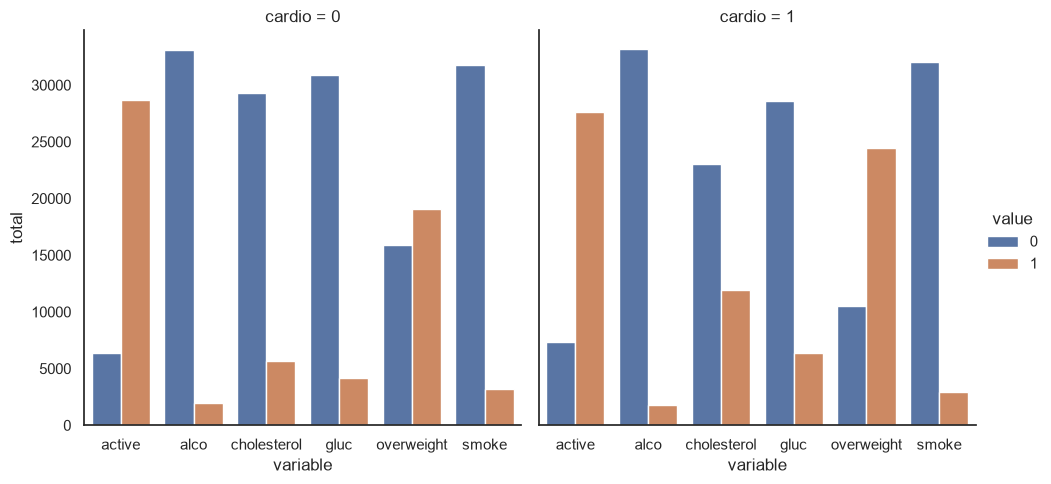

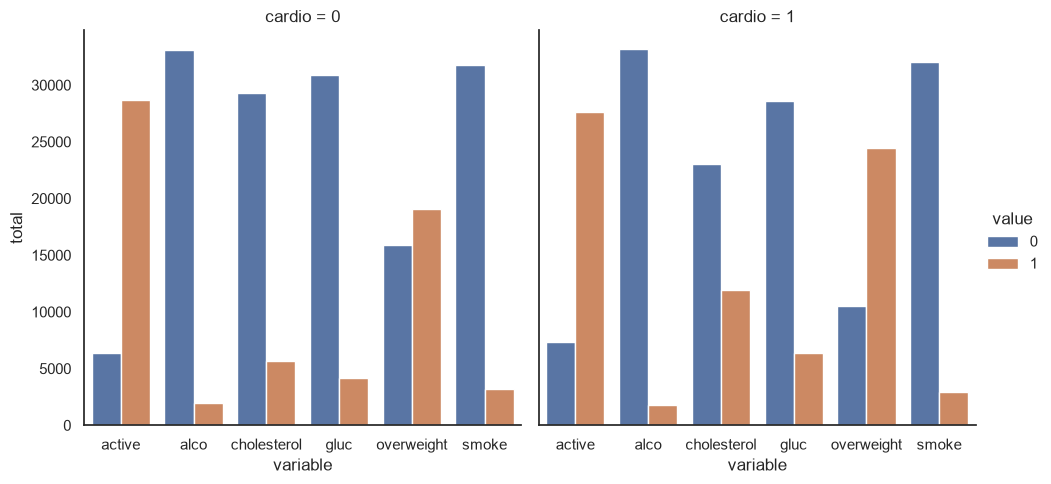

In [4]:
# Cell 4: Categorical Plot Analysis (draw_cat_plot)
# Melt data to long format
df_cat = pd.melt(
    df,
    id_vars=['cardio'],
    value_vars=['cholesterol', 'gluc', 'smoke', 'alco', 'active', 'overweight']
)

# Group and count
df_cat = df_cat.groupby(['cardio', 'variable', 'value']).size().reset_index(name='total')
print('Aggregated Categorical Features:')
display(df_cat.head(12))

# Draw and render catplot inline
cat_plot_fig = sns.catplot(
    data=df_cat,
    x='variable',
    y='total',
    hue='value',
    col='cardio',
    kind='bar'
).fig
plt.show()

# Call module implementation to verify file output
fig_cat = medical_data_visualizer.draw_cat_plot()
plt.show()

Original patient count: 70000
Cleaned patient count: 63259 (90.4% kept)


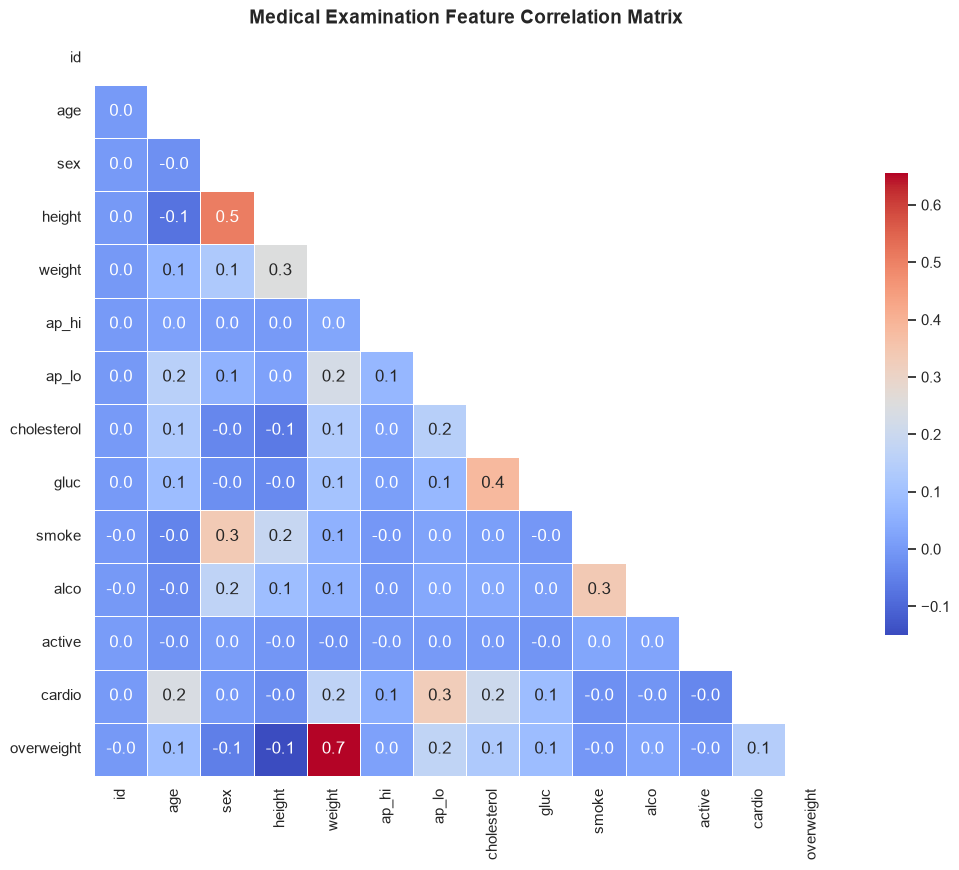

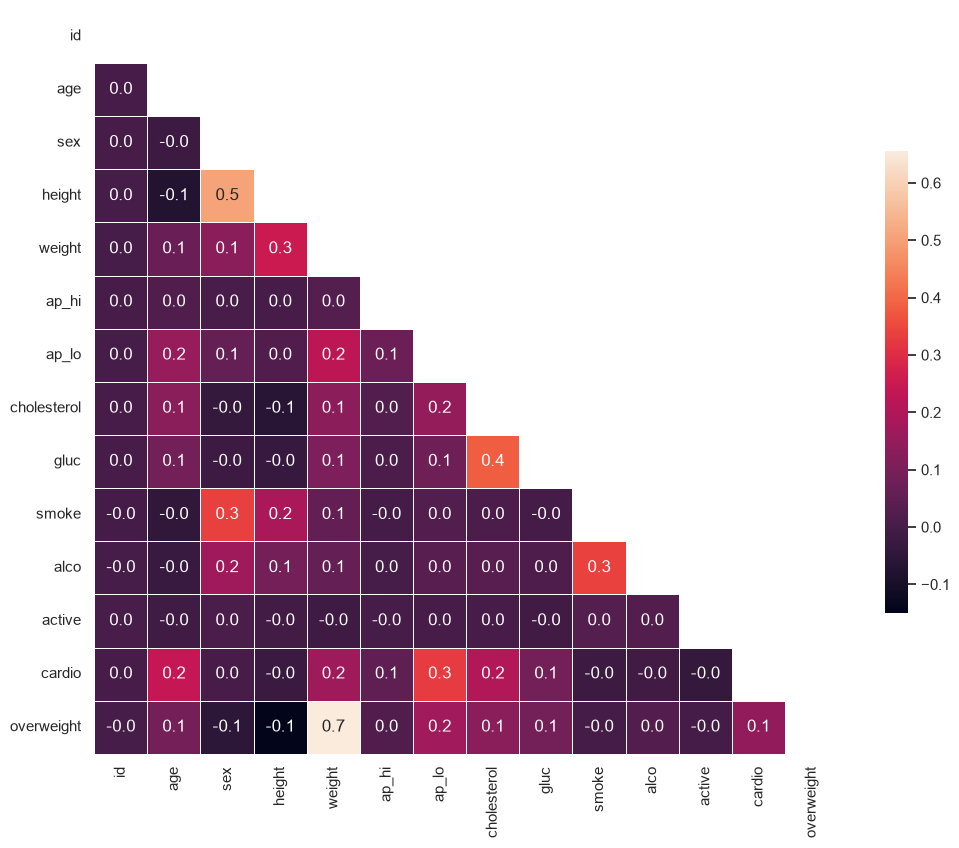

In [5]:
# Cell 5: Correlation Heat Map Analysis (draw_heat_map)
# Clean data by filtering diastolic <= systolic and height/weight within 2.5% to 97.5% quantiles
df_heat = df[
    (df['ap_lo'] <= df['ap_hi']) &
    (df['height'] >= df['height'].quantile(0.025)) &
    (df['height'] <= df['height'].quantile(0.975)) &
    (df['weight'] >= df['weight'].quantile(0.025)) &
    (df['weight'] <= df['weight'].quantile(0.975))
]

print(f'Original patient count: {len(df)}')
print(f'Cleaned patient count: {len(df_heat)} ({len(df_heat)/len(df)*100:.1f}% kept)')

# Calculate correlation matrix
corr = df_heat.corr()

# Generate upper triangle mask
mask = np.triu(np.ones_like(corr, dtype=bool))

# Draw heatmap
fig, ax = plt.subplots(figsize=(12, 12))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.1f',
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.5},
    ax=ax,
    cmap='coolwarm'
)
plt.title('Medical Examination Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.show()

# Call module implementation to verify file output
fig_heat = medical_data_visualizer.draw_heat_map()
plt.show()

test_bar_plot_number_of_bars (test_module.CatPlotTestCase.test_bar_plot_number_of_bars) ... 

ok


test_line_plot_labels (test_module.CatPlotTestCase.test_line_plot_labels) ... 

ok


test_heat_map_labels (test_module.HeatMapTestCase.test_heat_map_labels) ... 

ok


test_heat_map_values (test_module.HeatMapTestCase.test_heat_map_values) ... 

ok


----------------------------------------------------------------------
Ran 4 tests in 6.154s

OK


['0.0', '0.0', '-0.0', '0.0', '-0.1', '0.5', '0.0', '0.1', '0.1', '0.3', '0.0', '0.0', '0.0', '0.0', '0.0', '0.0', '0.2', '0.1', '0.0', '0.2', '0.1', '0.0', '0.1', '-0.0', '-0.1', '0.1', '0.0', '0.2', '0.0', '0.1', '-0.0', '-0.0', '0.1', '0.0', '0.1', '0.4', '-0.0', '-0.0', '0.3', '0.2', '0.1', '-0.0', '0.0', '0.0', '-0.0', '-0.0', '-0.0', '0.2', '0.1', '0.1', '0.0', '0.0', '0.0', '0.0', '0.3', '0.0', '-0.0', '0.0', '-0.0', '-0.0', '-0.0', '0.0', '0.0', '-0.0', '0.0', '0.0', '0.0', '0.2', '0.0', '-0.0', '0.2', '0.1', '0.3', '0.2', '0.1', '-0.0', '-0.0', '-0.0', '-0.0', '0.1', '-0.1', '-0.1', '0.7', '0.0', '0.2', '0.1', '0.1', '-0.0', '0.0', '-0.0', '0.1']

All 4 integration tests passed successfully!


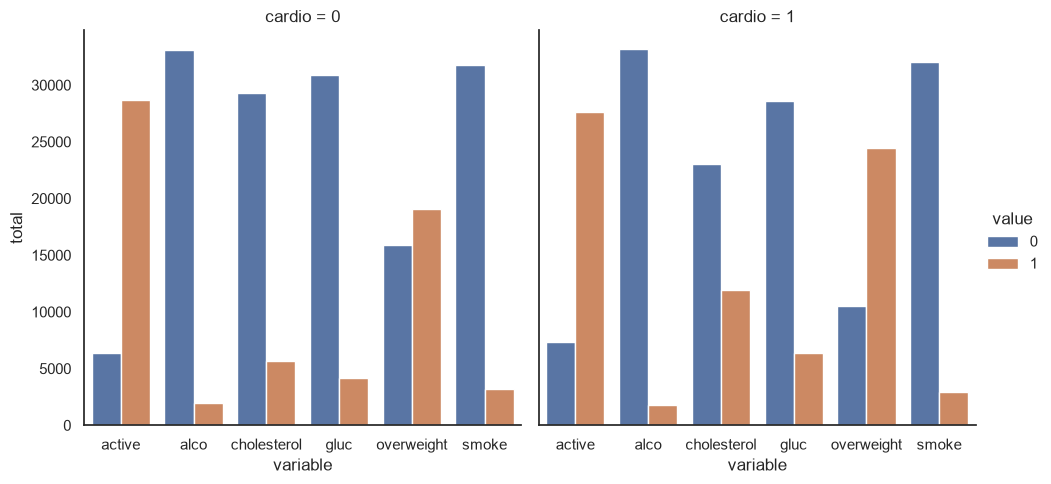

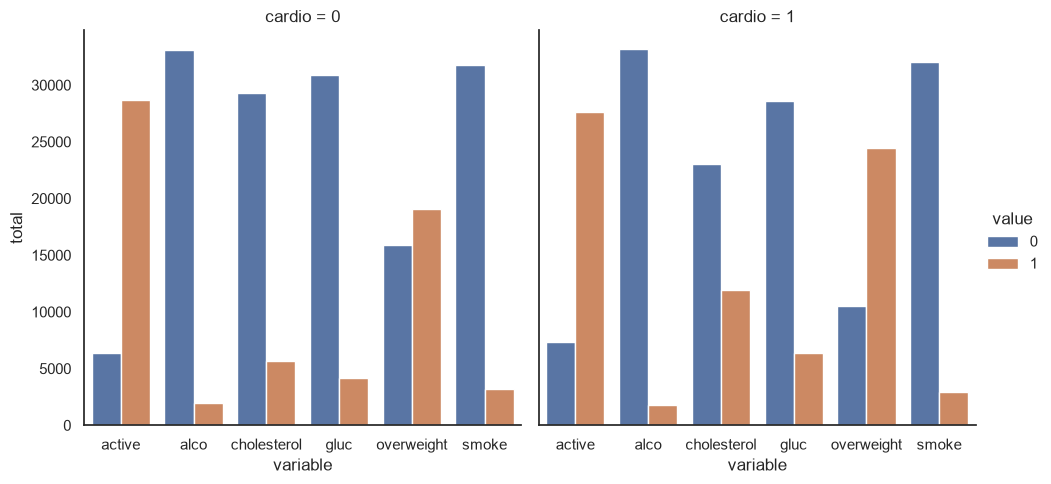

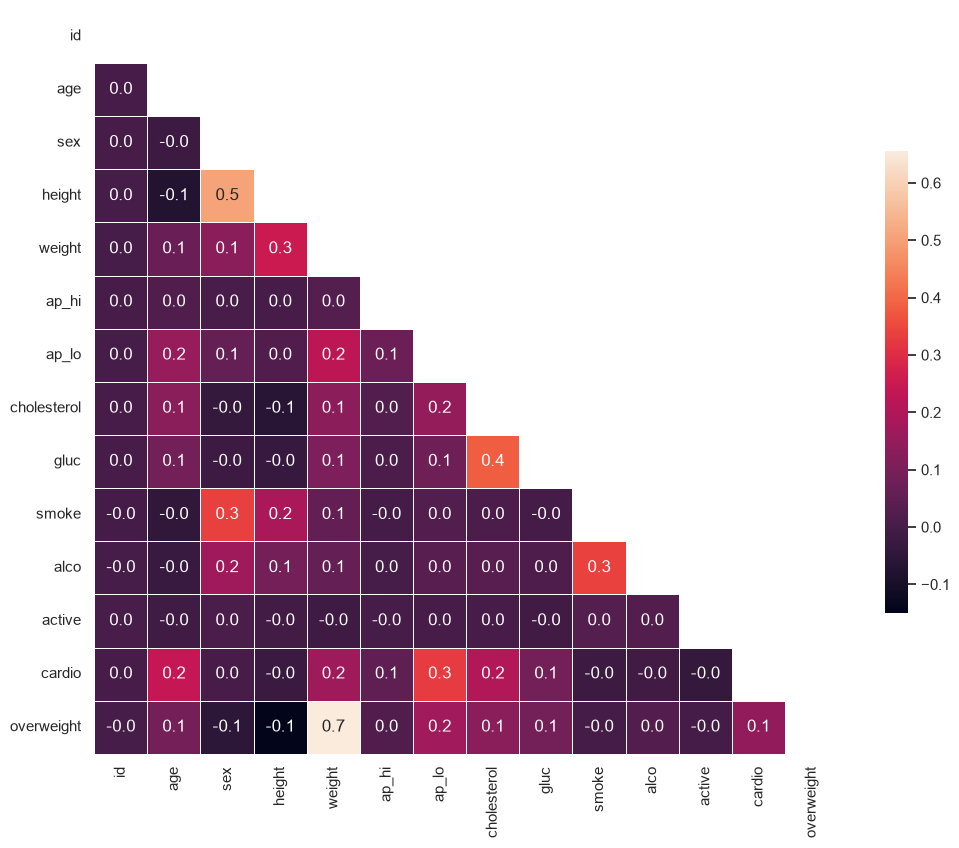

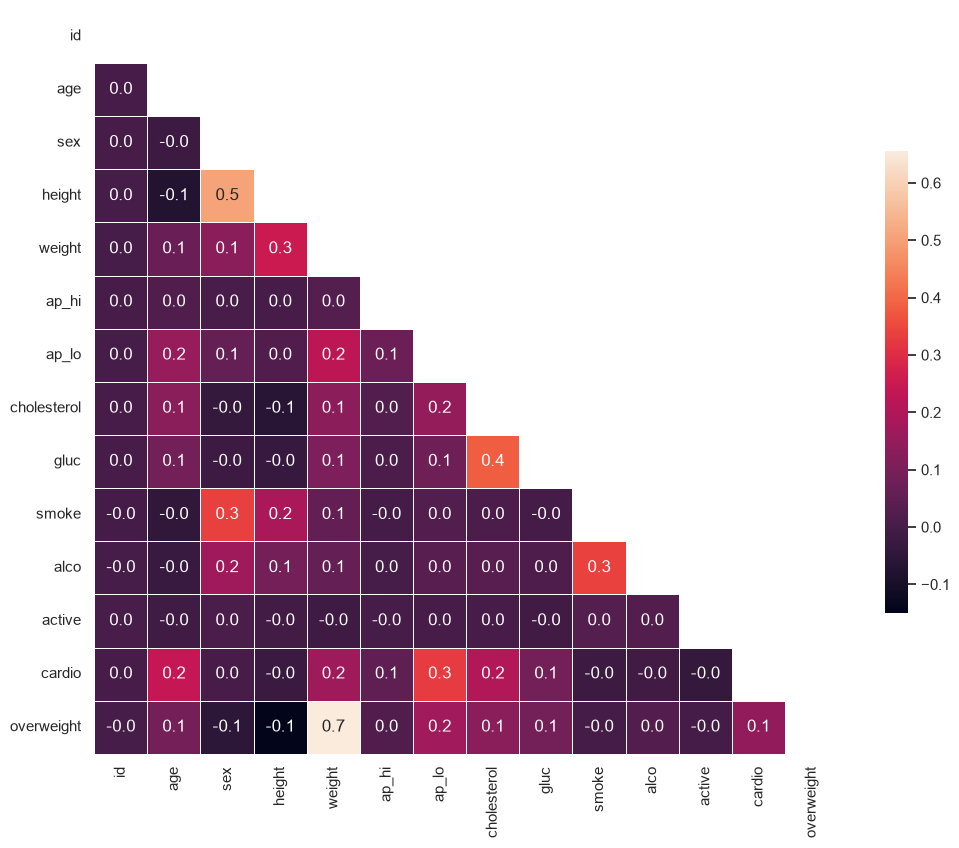

In [6]:
# Final Cell: Integration Test Runner
import unittest
import test_module

suite = unittest.defaultTestLoader.loadTestsFromModule(test_module)
runner = unittest.TextTestRunner(verbosity=2)
result = runner.run(suite)
assert result.wasSuccessful(), 'Medical Data Visualizer unit tests failed!'
print('\nAll 4 integration tests passed successfully!')